In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.70G/2.70G [02:03<00:00, 23.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import glob as gb
import cv2

In [11]:
train='/root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'

In [12]:
len(train)

161

In [13]:
size=224
# Improved training data generator with enhanced augmentation
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=45,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=(0.8, 1.2),
    rescale=1./255,
    validation_split=0.1
).flow_from_directory(
    train,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)
]

Found 63282 images belonging to 38 classes.


In [14]:
train_generator.class_indices

{'Apple___Apple_scab': 0,
 'Apple___Black_rot': 1,
 'Apple___Cedar_apple_rust': 2,
 'Apple___healthy': 3,
 'Blueberry___healthy': 4,
 'Cherry_(including_sour)___Powdery_mildew': 5,
 'Cherry_(including_sour)___healthy': 6,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7,
 'Corn_(maize)___Common_rust_': 8,
 'Corn_(maize)___Northern_Leaf_Blight': 9,
 'Corn_(maize)___healthy': 10,
 'Grape___Black_rot': 11,
 'Grape___Esca_(Black_Measles)': 12,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13,
 'Grape___healthy': 14,
 'Orange___Haunglongbing_(Citrus_greening)': 15,
 'Peach___Bacterial_spot': 16,
 'Peach___healthy': 17,
 'Pepper,_bell___Bacterial_spot': 18,
 'Pepper,_bell___healthy': 19,
 'Potato___Early_blight': 20,
 'Potato___Late_blight': 21,
 'Potato___healthy': 22,
 'Raspberry___healthy': 23,
 'Soybean___healthy': 24,
 'Squash___Powdery_mildew': 25,
 'Strawberry___Leaf_scorch': 26,
 'Strawberry___healthy': 27,
 'Tomato___Bacterial_spot': 28,
 'Tomato___Early_blight': 29,
 'Toma

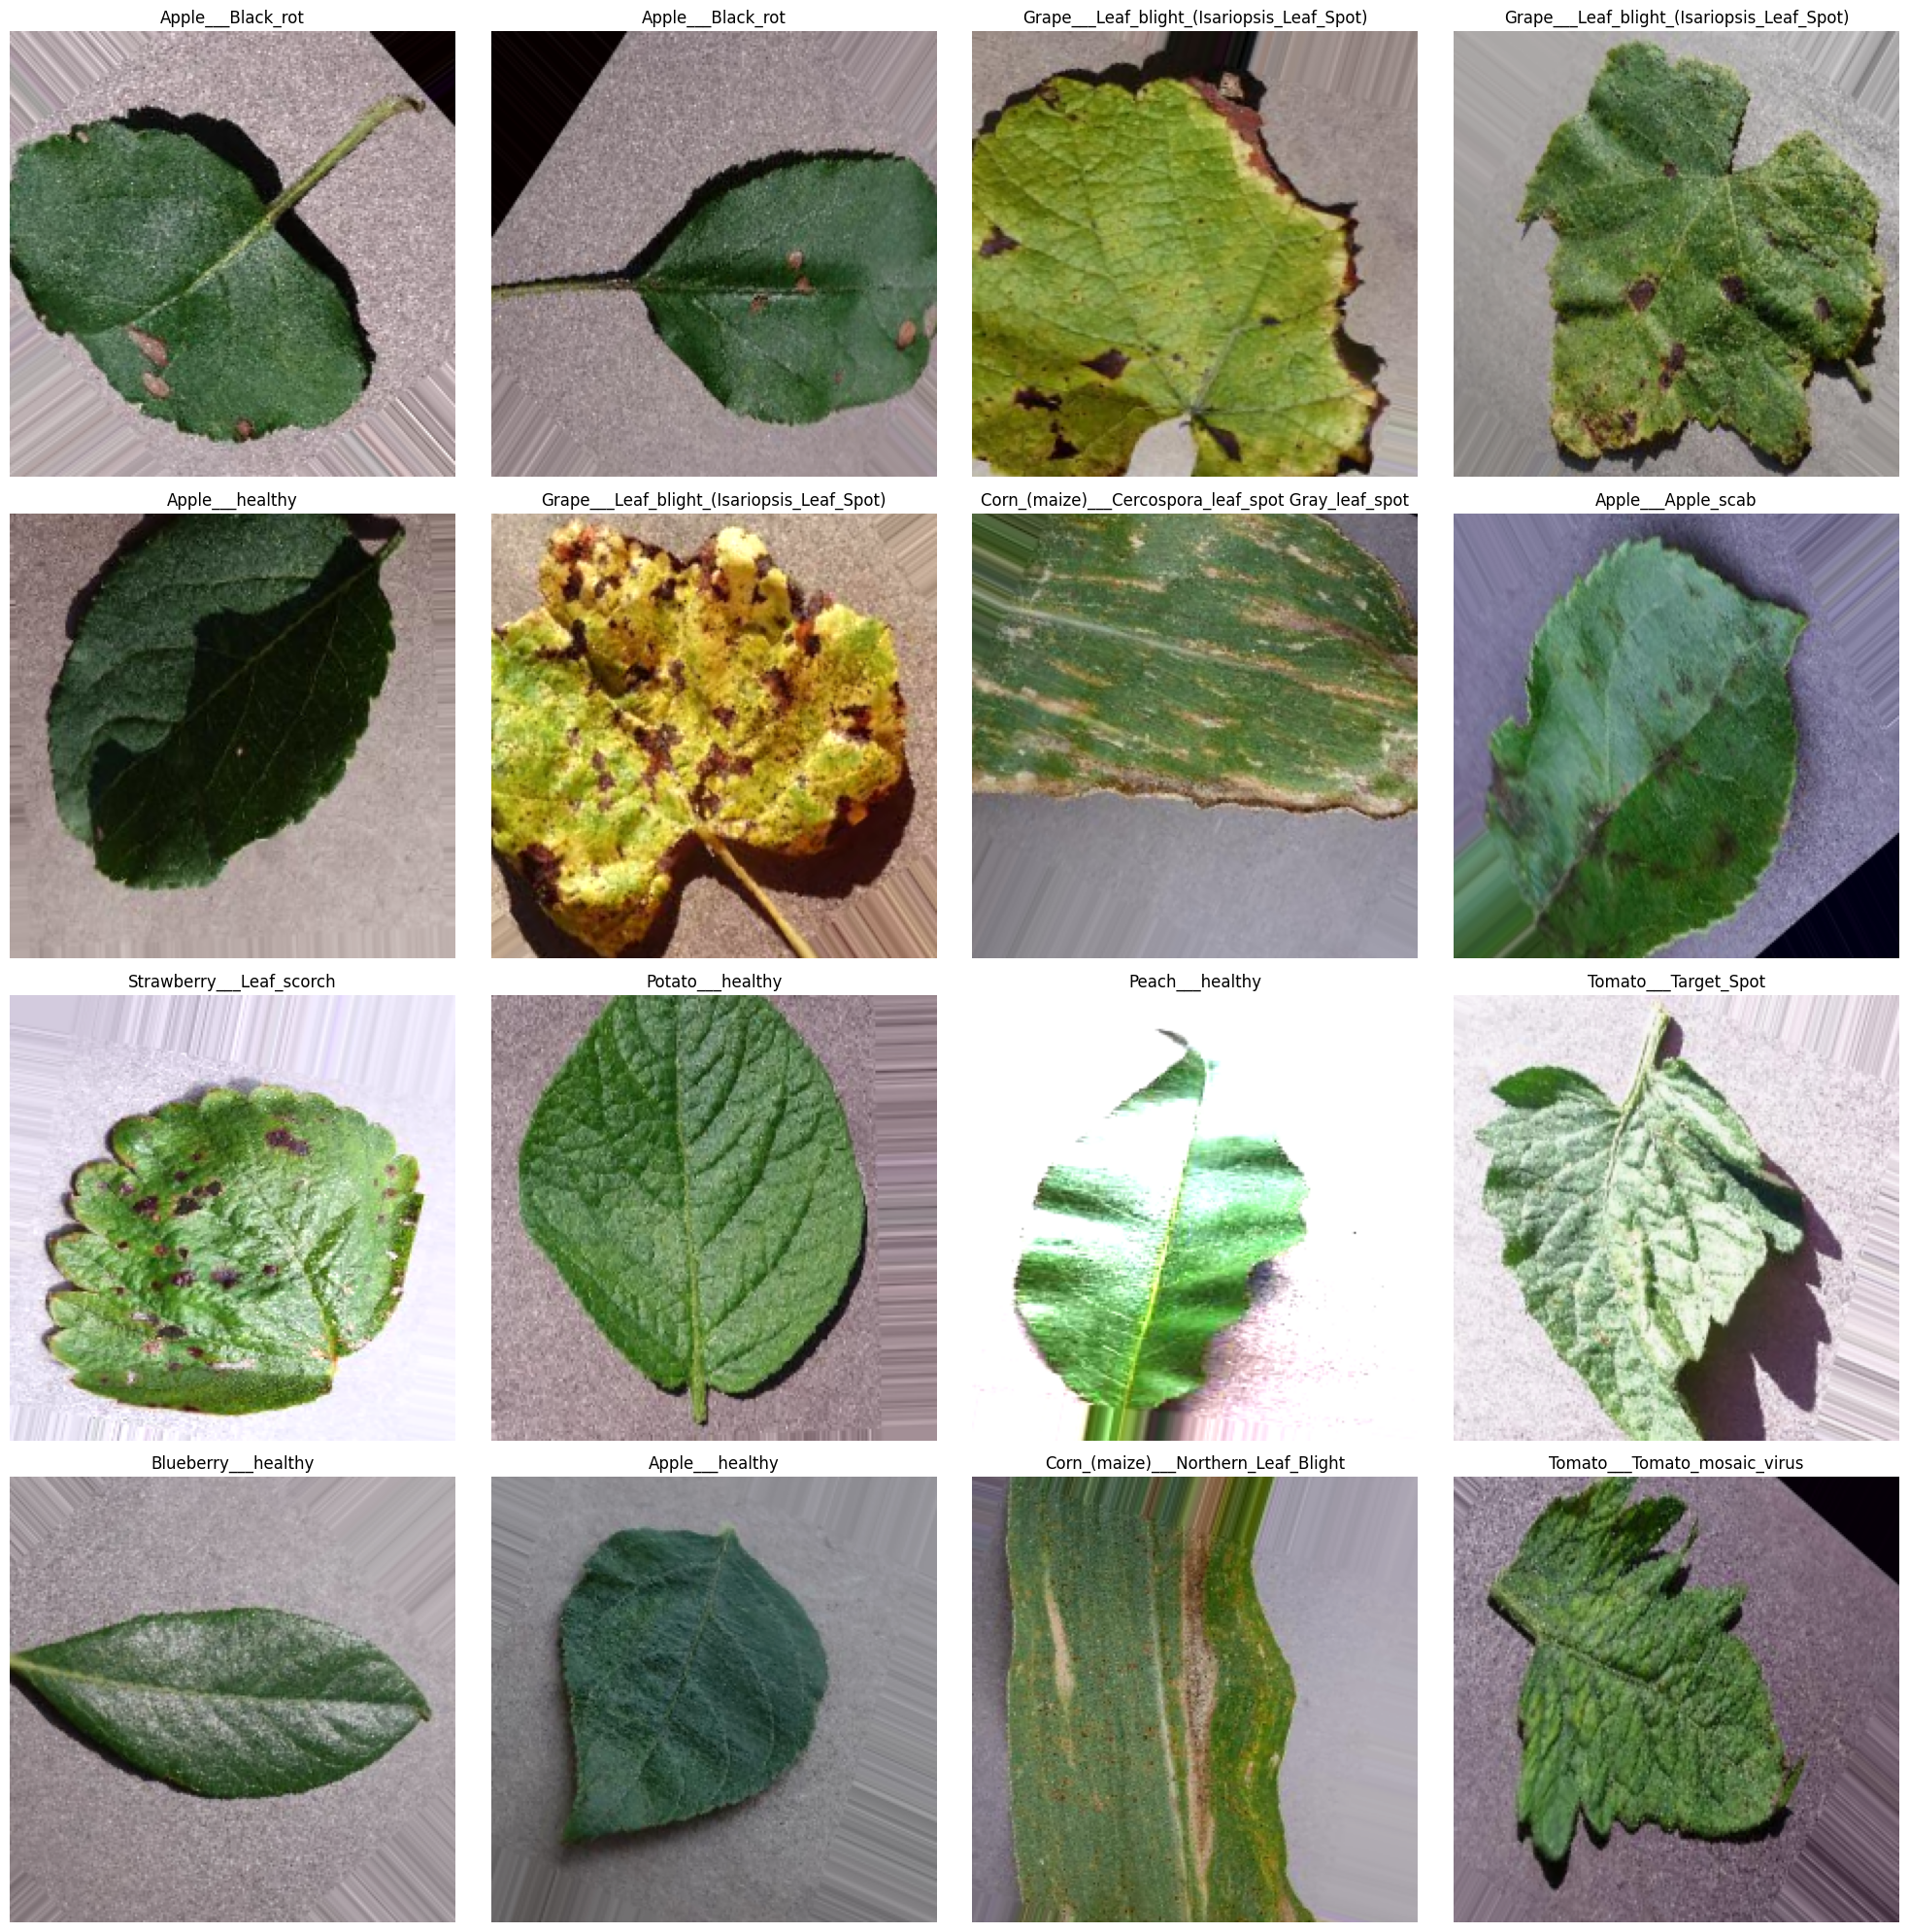

In [15]:
import numpy as np
import matplotlib.pyplot as plt

classes = list(train_generator.class_indices.keys())  # Get class labels

plt.figure(figsize=(20, 20))  # Set figure size

for X_batch, y_batch in train_generator:
    for i in range(16):  # Display 16 images
        plt.subplot(4, 4, i + 1)  # Create 4x4 grid
        plt.imshow(X_batch[i])  # Display image
        plt.title(classes[np.argmax(y_batch[i])])  # Corrected class label extraction
        plt.axis('off')
    plt.tight_layout()
    plt.show()  # Show all images in a single figure
    break  # Break after first batch


In [16]:
valid='/root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'

In [17]:
valid_generator=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1/255.0,
    preprocessing_function=None,
    validation_split=0.1,
).flow_from_directory(
    valid,
    target_size=(size,size),
    batch_size=164,
    class_mode='categorical',
    color_mode='rgb',
    subset='validation',
    shuffle=False
)


Found 1742 images belonging to 38 classes.


In [18]:
test='/root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'
test_generator=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1/255.0,
    preprocessing_function=None,
).flow_from_directory(test,
                      target_size=(224,224),
                      batch_size=164,
                      class_mode='categorical',
                      color_mode='rgb',
                      shuffle=False
)

Found 17572 images belonging to 38 classes.


In [19]:
test_generator.class_indices

{'Apple___Apple_scab': 0,
 'Apple___Black_rot': 1,
 'Apple___Cedar_apple_rust': 2,
 'Apple___healthy': 3,
 'Blueberry___healthy': 4,
 'Cherry_(including_sour)___Powdery_mildew': 5,
 'Cherry_(including_sour)___healthy': 6,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7,
 'Corn_(maize)___Common_rust_': 8,
 'Corn_(maize)___Northern_Leaf_Blight': 9,
 'Corn_(maize)___healthy': 10,
 'Grape___Black_rot': 11,
 'Grape___Esca_(Black_Measles)': 12,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13,
 'Grape___healthy': 14,
 'Orange___Haunglongbing_(Citrus_greening)': 15,
 'Peach___Bacterial_spot': 16,
 'Peach___healthy': 17,
 'Pepper,_bell___Bacterial_spot': 18,
 'Pepper,_bell___healthy': 19,
 'Potato___Early_blight': 20,
 'Potato___Late_blight': 21,
 'Potato___healthy': 22,
 'Raspberry___healthy': 23,
 'Soybean___healthy': 24,
 'Squash___Powdery_mildew': 25,
 'Strawberry___Leaf_scorch': 26,
 'Strawberry___healthy': 27,
 'Tomato___Bacterial_spot': 28,
 'Tomato___Early_blight': 29,
 'Toma

In [4]:
from tensorflow import keras
from tensorflow.keras.layers import BatchNormalization, Dropout, GlobalAveragePooling2D, LeakyReLU

model = keras.models.Sequential()

model.add(keras.layers.Conv2D(filters=32, kernel_size=3, strides=1, padding='same',
                              name="Conv1", input_shape=(224, 224, 3)))
model.add(LeakyReLU(alpha=0.1))
model.add(BatchNormalization(name="BatchNorm1"))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool1"))

model.add(keras.layers.Conv2D(filters=64, kernel_size=3, strides=1, padding='same', name='Conv2'))
model.add(LeakyReLU(alpha=0.1))
model.add(BatchNormalization(name="BatchNorm2"))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool2"))

model.add(keras.layers.Conv2D(filters=128, kernel_size=3, strides=1, padding='same', name='Conv3'))
model.add(LeakyReLU(alpha=0.1))
model.add(BatchNormalization(name="BatchNorm3"))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool3"))

model.add(keras.layers.Conv2D(filters=256, kernel_size=3, strides=1, padding='same', name='Conv4'))
model.add(LeakyReLU(alpha=0.1))
model.add(BatchNormalization(name="BatchNorm4"))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool4"))

# Additional Conv Layer
model.add(keras.layers.Conv2D(filters=512, kernel_size=3, strides=1, padding='same', name='Conv5'))
model.add(LeakyReLU(alpha=0.1))
model.add(BatchNormalization(name="BatchNorm5"))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool5"))

# Replacing Flatten with GAP
model.add(GlobalAveragePooling2D(name='GAP'))

# Dense Layers
model.add(keras.layers.Dense(128, name='Dense1'))
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.5, name="Dropout1"))

model.add(keras.layers.Dense(64, name='Dense2'))
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.5, name="Dropout2"))

# Output Layer
model.add(keras.layers.Dense(38, activation=keras.activations.softmax, name='Output'))

print(model.summary())


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                       │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 224, 224, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ BatchNorm1 (BatchNormalization)      │ (None, 224, 224, 32)        │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Pool1 (MaxPooling2D)                 │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv2 (Conv2D)                       │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ BatchNorm2 (BatchNormalization)      │ (None, 112, 112, 64)        │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Pool2 (MaxPooling2D)                 │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv3 (Conv2D)                       │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ BatchNorm3 (BatchNormalization)      │ (None, 56, 56, 128)         │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Pool3 (MaxPooling2D)                 │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv4 (Conv2D)                       │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ BatchNorm4 (BatchNormalization)      │ (None, 28, 28, 256)         │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Pool4 (MaxPooling2D)                 │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv5 (Conv2D)                       │ (None, 14, 14, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_4 (LeakyReLU)            │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ BatchNorm5 (BatchNormalization)      │ (None, 14, 14, 512)         │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Pool5 (MaxPooling2D)                 │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ GAP (GlobalAveragePooling2D)         │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,648,934 (6.29 MB)

 Trainable params: 1,646,950 (6.28 MB)

 Non-trainable params: 1,984 (7.75 KB)

None


In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss', patience=10, mode='min', restore_best_weights=True, verbose=1)

model_checkpoint = ModelCheckpoint('best_model.weights.h5', monitor='val_loss', save_best_only=True,
                                   save_weights_only=True, mode='min', verbose=1)


model_ReduceLRonPlateau = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=7,
                                            min_lr=1e-6, mode='min', verbose=1)

callbacks = [early_stopping, model_checkpoint, model_ReduceLRonPlateau]


In [6]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy', 'precision', 'recall'])

In [20]:
history = model.fit(train_generator, epochs=5, validation_data=valid_generator, callbacks=callbacks)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.2401 - loss: 2.7802 - precision: 0.5843 - recall: 0.0913

1978/1978 ━━━━━━━━━━━━━━━━━━━━ 889s 442ms/step - accuracy: 0.2401 - loss: 2.7799 - precision: 0.5843 - recall: 0.0913 - val_accuracy: 0.5499 - val_loss: 1.4030 - val_precision: 0.7299 - val_recall: 0.4110 - learning_rate: 0.0010
Epoch 2/5
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 852s 431ms/step - accuracy: 0.5903 - loss: 1.3508 - precision: 0.7486 - recall: 0.4256 - val_accuracy: 0.4495 - val_loss: 2.7756 - val_precision: 0.5014 - val_recall: 0.4099 - learning_rate: 0.0010
Epoch 3/5
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.7265 - loss: 0.8976 - precision: 0.8208 - recall: 0.6269

1978/1978 ━━━━━━━━━━━━━━━━━━━━ 845s 427ms/step - accuracy: 0.7266 - loss: 0.8975 - precision: 0.8208 - recall: 0.6269 - val_accuracy: 0.8192 - val_loss: 0.7028 - val_precision: 0.8519 - val_recall: 0.7893 - learning_rate: 0.0010
Epoch 4/5
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 839s 424ms/step - accuracy: 0.7922 - loss: 0.6864 - precision: 0.8544 - recall: 0.7249 - val_accuracy: 0.7113 - val_loss: 1.3734 - val_precision: 0.7483 - val_recall: 0.6912 - learning_rate: 0.0010
Epoch 5/5
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.8322 - loss: 0.5485 - precision: 0.8802 - recall: 0.7851

1978/1978 ━━━━━━━━━━━━━━━━━━━━ 842s 425ms/step - accuracy: 0.8322 - loss: 0.5485 - precision: 0.8802 - recall: 0.7851 - val_accuracy: 0.8794 - val_loss: 0.3804 - val_precision: 0.9134 - val_recall: 0.8594 - learning_rate: 0.0010


In [21]:
import seaborn as sns

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

precision = history.history['precision']
val_precision = history.history['val_precision']

recall = history.history['recall']
val_recall = history.history['val_recall']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

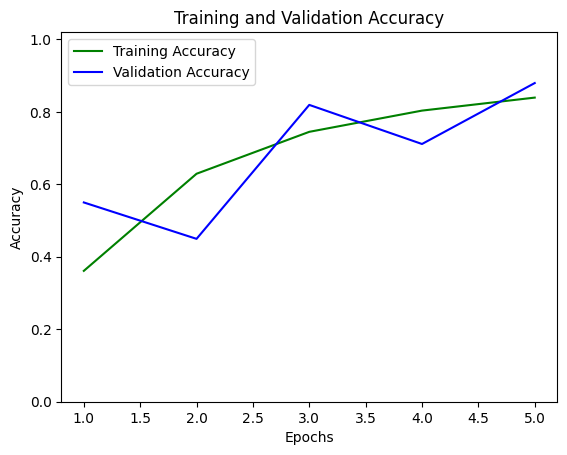

In [22]:

plt.plot(epochs, acc, color='green', label='Training Accuracy')
plt.plot(epochs, val_acc, color='blue', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1.02)
plt.show()

In [23]:

model_evaluate = model.evaluate(test_generator)
print("loss:", model_evaluate[0])
print("accuracy:", model_evaluate[1])
print("precision:", model_evaluate[2])
print("recall:", model_evaluate[3])


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


108/108 ━━━━━━━━━━━━━━━━━━━━ 37s 344ms/step - accuracy: 0.9140 - loss: 0.2775 - precision: 0.9327 - recall: 0.8998
loss: 0.35416916012763977
accuracy: 0.8873207569122314
precision: 0.9146232008934021
recall: 0.8681424856185913


In [24]:
model.save('cnn_model.keras')